# No Nonsense Linear Regression: Predicting Response Times from Consumer Complaint Text

**Companion notebook to the [Linear Regression Primer](../Linear_Regression_Primer.md)**

This notebook is a working example that demonstrates linear regression concepts from the primer using real-world NLP data. Each section references the relevant primer section so you can jump between theory and application.

Every day, thousands of consumers file complaints with the CFPB about financial products. Each complaint contains a narrative — raw text describing what went wrong. Some complaints get a response in a day. Others take weeks.

**The question:** Can the *text* of a complaint tell us anything about how long it takes a company to respond?

We'll extract NLP features from complaint narratives, throw them into a linear regression, and see what sticks. Along the way, we'll cover the stuff most tutorials skip: assumption violations, coefficient interpretation with text features, regularization, and what to do when your R² is underwhelming (spoiler: that's normal with real data).

**What you'll need:**
- The CFPB complaint sample (see `data/README.md` for download instructions)
- Python 3.10+ with the packages in `requirements.txt`
- ~15 minutes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

%matplotlib inline

## 1. The Data

The CFPB Consumer Complaints Database is public, free, and messy in all the right ways. We've already sampled 50K complaints that have both narrative text and a valid response time. Let's load it.

In [2]:
data_path = Path("../data/complaints_sample.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Sample data not found. Run 'python data/prepare_data.py' first. "
        "See data/README.md for download instructions."
    )

df = pd.read_csv(data_path, parse_dates=["Date received", "Date sent to company"])
print(f"Shape: {df.shape}")
df.head(3)

Shape: (50000, 12)


,Date received,Product,Sub-product,Issue,Consumer complaint narrative,Company,State,Company response to consumer,Timely response?,Consumer disputed?,Date sent to company,response_time_days
0,2025-09-27,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Date : XX/XX/XXXX Via Certified Mail Return Re...,"EQUIFAX, INC.",CA,Closed with non-monetary relief,Yes,NaN,2025-09-27,0
1,2021-05-07,Debt collection,Private student loan debt,Attempts to collect debt not owed,I was advised that would send to their manager...,USCB Corporation,TX,Closed with explanation,Yes,NaN,2021-05-07,0
2,2020-11-11,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,I am filing a complaint against PayPal. I file...,"Paypal Holdings, Inc",CO,Closed with explanation,Yes,NaN,2020-11-24,13


In [3]:
# Our target: how many days between CFPB receiving the complaint and forwarding it to the company
df["response_time_days"].describe()

count    50000.000000
mean         0.723480
std          5.959638
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        699.000000
Name: response_time_days, dtype: float64

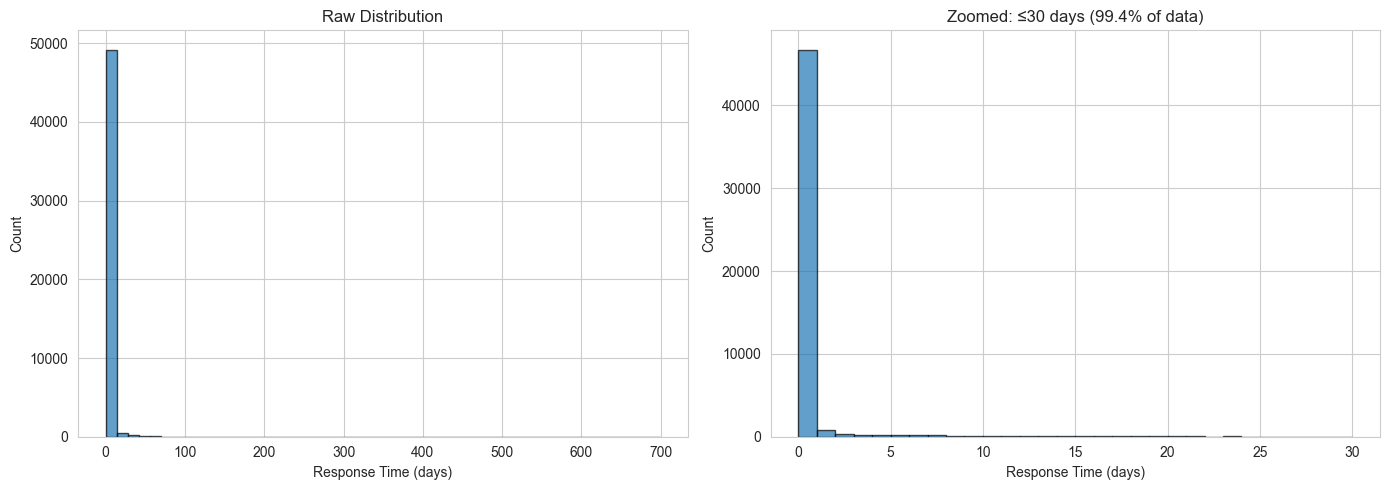

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df["response_time_days"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Response Time (days)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw Distribution")

# Zoomed in (drop extreme outliers for visualization)
reasonable = df[df["response_time_days"] <= 30]
axes[1].hist(reasonable["response_time_days"], bins=30, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Response Time (days)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Zoomed: ≤30 days ({len(reasonable)/len(df)*100:.1f}% of data)")

plt.tight_layout()
plt.show()

That spike at 0-1 days? Most complaints get forwarded immediately. The long tail is where it gets interesting.

For modeling, we'll cap response time at 30 days. Anything beyond that is likely a process anomaly, not something the complaint *text* can explain.

In [5]:
# Filter to reasonable response times
df = df[df["response_time_days"] <= 30].copy()
print(f"After filtering: {len(df):,} records")
print(f"Mean response time: {df['response_time_days'].mean():.2f} days")
print(f"Median response time: {df['response_time_days'].median():.1f} days")

After filtering: 49,703 records
Mean response time: 0.41 days
Median response time: 0.0 days


In [6]:
# Quick look at what we're working with
sample_text = df["Consumer complaint narrative"].iloc[0]
print(f"Sample complaint ({len(sample_text)} chars):")
print(sample_text[:500] + "..." if len(sample_text) > 500 else sample_text)

Sample complaint (2881 chars):
Date : XX/XX/XXXX Via Certified Mail Return Receipt Requested To : XXXX XXXX XXXXXXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXXXXXX Phone : ( XXXX ) XXXX From : XXXX XXXX XXXX XXXX XXXX XXXXXXXX XXXX XXXX XXXX XXXX XXXXXXXX DOB : XX/XX/XXXX SSN ( Last 4 ) : XXXX Phone : ( XXXX ) XXXX Email : XXXX Subject : FCRA 623 ( b ) Direct Dispute Account # XXXX Dear XXXX XXXX XXXX XXXX Department, I am submitting a formal direct dispute regarding the tradeline you are furnishing to Equifax ( and ot...


## 2. Feature Engineering from Text

> **Primer Reference**: [Section 7 — Feature Engineering & Variable Selection](../Linear_Regression_Primer.md#7-feature-engineering--variable-selection)

Here's where the NLP meets the regression. We need to turn raw complaint text into numbers that a linear model can work with.

We'll extract four types of features:
1. **Basic text stats** — length, word count, sentence count
2. **Readability** — how complex is the writing?
3. **Sentiment** — how negative/emotional is the complaint?
4. **TF-IDF** — which specific words matter?

Each of these is a hypothesis: *does this text property predict how long a company takes to respond?*

In [7]:
# Basic text features — looks simple but these are surprisingly informative
df["text_length"] = df["Consumer complaint narrative"].str.len()
df["word_count"] = df["Consumer complaint narrative"].str.split().str.len()
df["sentence_count"] = df["Consumer complaint narrative"].str.count(r'[.!?]+')
df["avg_word_length"] = df["text_length"] / df["word_count"]
df["words_per_sentence"] = df["word_count"] / df["sentence_count"].replace(0, 1)

print("Basic text features:")
df[["text_length", "word_count", "sentence_count", "avg_word_length", "words_per_sentence"]].describe().round(1)

Basic text features:


,text_length,word_count,sentence_count,avg_word_length,words_per_sentence
count,49703.0,49703.0,49703.0,49703.0,49703.0
mean,1006.7,175.2,9.7,5.8,21.9
std,1270.7,219.3,12.5,4.3,21.2
min,12.0,1.0,0.0,2.1,0.1
25%,342.0,60.0,3.0,5.4,13.6
50%,662.0,115.0,6.0,5.7,18.0
75%,1204.0,210.0,12.0,6.0,23.4
max,32150.0,5625.0,453.0,858.0,1055.0


In [8]:
import textstat

# Readability scores — how complex is the writing?
# Flesch Reading Ease: higher = easier to read (60-70 is plain English)
df["flesch_reading_ease"] = df["Consumer complaint narrative"].apply(textstat.flesch_reading_ease)

# Flesch-Kincaid Grade Level: roughly maps to US school grade level
df["flesch_kincaid_grade"] = df["Consumer complaint narrative"].apply(textstat.flesch_kincaid_grade)

print("Readability scores:")
df[["flesch_reading_ease", "flesch_kincaid_grade"]].describe().round(1)

Readability scores:


,flesch_reading_ease,flesch_kincaid_grade
count,49703.0,49703.0
mean,52.1,11.3
std,84.0,12.9
min,-16206.6,-3.0
25%,40.6,8.0
50%,54.2,10.5
75%,67.1,13.0
max,120.2,2274.0


In [9]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

# VADER sentiment — designed for social media text, works well enough on complaints
sentiment_scores = df["Consumer complaint narrative"].apply(lambda x: sia.polarity_scores(x))
df["sentiment_neg"] = sentiment_scores.apply(lambda x: x["neg"])
df["sentiment_neu"] = sentiment_scores.apply(lambda x: x["neu"])
df["sentiment_pos"] = sentiment_scores.apply(lambda x: x["pos"])
df["sentiment_compound"] = sentiment_scores.apply(lambda x: x["compound"])

print("Sentiment scores:")
df[["sentiment_neg", "sentiment_neu", "sentiment_pos", "sentiment_compound"]].describe().round(3)

Sentiment scores:


,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
count,49703.000,49703.000,49703.000,49703.000
mean,0.094,0.812,0.095,-0.034
std,0.065,0.087,0.062,0.679
min,0.000,0.143,0.000,-1.000
25%,0.048,0.757,0.052,-0.727
50%,0.083,0.817,0.087,-0.026
75%,0.131,0.874,0.130,0.612
max,0.688,1.000,0.664,1.000


No surprise — complaints skew negative. But there's variance, and that's what we need.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF: the workhorse of text-to-numbers
# We'll limit to 50 features to keep the model interpretable
tfidf = TfidfVectorizer(
    max_features=50,
    stop_words="english",
    min_df=50,       # appear in at least 50 docs
    max_df=0.95,     # not in >95% of docs
    ngram_range=(1, 2),
)

tfidf_matrix = tfidf.fit_transform(df["Consumer complaint narrative"])
tfidf_feature_names = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=df.index)

print(f"TF-IDF features: {len(tfidf_feature_names)}")
print(f"Top terms: {', '.join(tfidf.get_feature_names_out()[:10])}...")

TF-IDF features: 50
Top terms: 00, 15, account, accounts, act, agency, balance, bank, card, company...


In [11]:
# Combine all features
nlp_features = [
    "text_length", "word_count", "sentence_count", "avg_word_length", "words_per_sentence",
    "flesch_reading_ease", "flesch_kincaid_grade",
    "sentiment_neg", "sentiment_neu", "sentiment_pos", "sentiment_compound",
]

X = pd.concat([df[nlp_features], tfidf_df], axis=1)
y = df["response_time_days"]

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}")

Feature matrix: (49703, 61)
Target: (49703,)


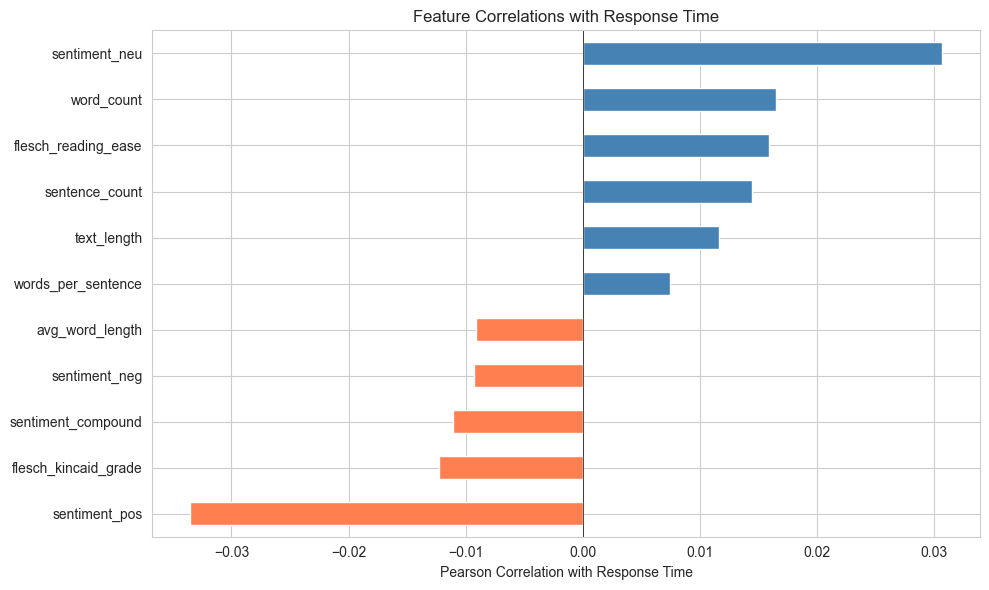


Don't panic if these are small. With real-world text data,
correlations of 0.05-0.15 are typical. We're not predicting stock prices here.


In [12]:
# Quick look at correlations between our hand-crafted features and the target
correlations = df[nlp_features + ["response_time_days"]].corr()["response_time_days"].drop("response_time_days").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
correlations.plot(kind="barh", ax=ax, color=["steelblue" if v > 0 else "coral" for v in correlations])
ax.set_xlabel("Pearson Correlation with Response Time")
ax.set_title("Feature Correlations with Response Time")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nDon't panic if these are small. With real-world text data,")
print("correlations of 0.05-0.15 are typical. We're not predicting stock prices here.")

## 3. Building the Model

> **Primer Reference**: [Section 2 — OLS Estimation](../Linear_Regression_Primer.md#2-ordinary-least-squares-ols-estimation) | [Section 5 — Model Evaluation](../Linear_Regression_Primer.md#5-model-evaluation-metrics)

No ceremony. Split the data, fit the model, see what happens.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features — important when mixing text length (100s) with TF-IDF (0-1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)

print(f"R² (test):  {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} days")
print(f"MAE:        {mean_absolute_error(y_test, y_pred):.4f} days")
print(f"\nBaseline (always predict mean): MAE = {(y_test - y_test.mean()).abs().mean():.4f} days")

R² (test):  0.0189
RMSE:       2.2824 days
MAE:        0.7494 days

Baseline (always predict mean): MAE = 0.7490 days


**Let's talk about that R².**

> **Primer Reference**: [Section 5.1 — Coefficient of Determination](../Linear_Regression_Primer.md#51-coefficient-of-determination-r2)

If you're disappointed, good — you're paying attention. A low R² on real-world text data is *expected*. Here's why:

1. Response time is driven primarily by *company processes*, not complaint text
2. We're using surface-level NLP features — they capture writing style, not content depth
3. There's massive noise in the target (holidays, staffing, backlogs)

The value isn't in the R². It's in the *coefficients* — what text features are associated with longer or shorter response times, even if the effect is small. That's the story.

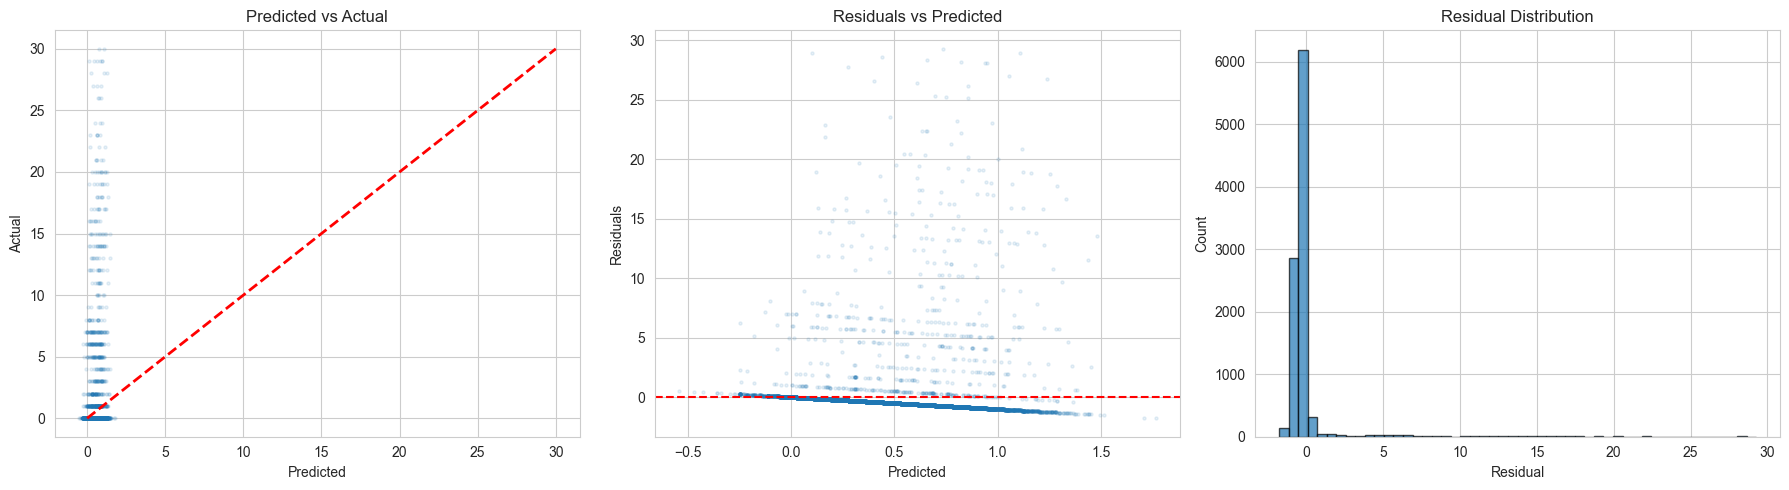

In [14]:
# Residual plots — the real diagnostic
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals = y_test - y_pred

# Predicted vs Actual
axes[0].scatter(y_pred, y_test, alpha=0.1, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Predicted vs Actual")

# Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.1, s=5)
axes[1].axhline(y=0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted")

# Residual distribution
axes[2].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 4. Interpreting the Coefficients

> **Primer Reference**: [Section 1.2 — Multiple Linear Regression](../Linear_Regression_Primer.md#12-multiple-linear-regression) (coefficient interpretation) | [Section 4.1 — t-test](../Linear_Regression_Primer.md#41-testing-individual-coefficients-t-test)

This is where linear regression earns its keep. Unlike a black-box model, we can look at every coefficient and say *exactly* what it means.

In [15]:
# Coefficient table
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_,
    "abs_coefficient": np.abs(model.coef_),
}).sort_values("abs_coefficient", ascending=False)

print("Top 15 features by absolute coefficient (standardized):")
print("(Coefficient = change in predicted response time per 1 SD change in feature)")
print()
coef_df.head(15)[["feature", "coefficient"]].to_string(index=False)

Top 15 features by absolute coefficient (standardized):
(Coefficient = change in predicted response time per 1 SD change in feature)



'             feature  coefficient\n flesch_reading_ease     0.817928\n         text_length    -0.495640\n          word_count     0.478367\n     avg_word_length     0.438300\nflesch_kincaid_grade     0.401970\n            tfidf_xx    -0.321005\n         tfidf_xx xx     0.320119\n     tfidf_xxxx xxxx    -0.242479\n          tfidf_xxxx     0.203937\n       sentiment_neu     0.179168\n       sentiment_neg     0.149233\n       sentiment_pos     0.125953\n       tfidf_company     0.092642\n     tfidf_complaint    -0.055319\n          tfidf_debt     0.054329'

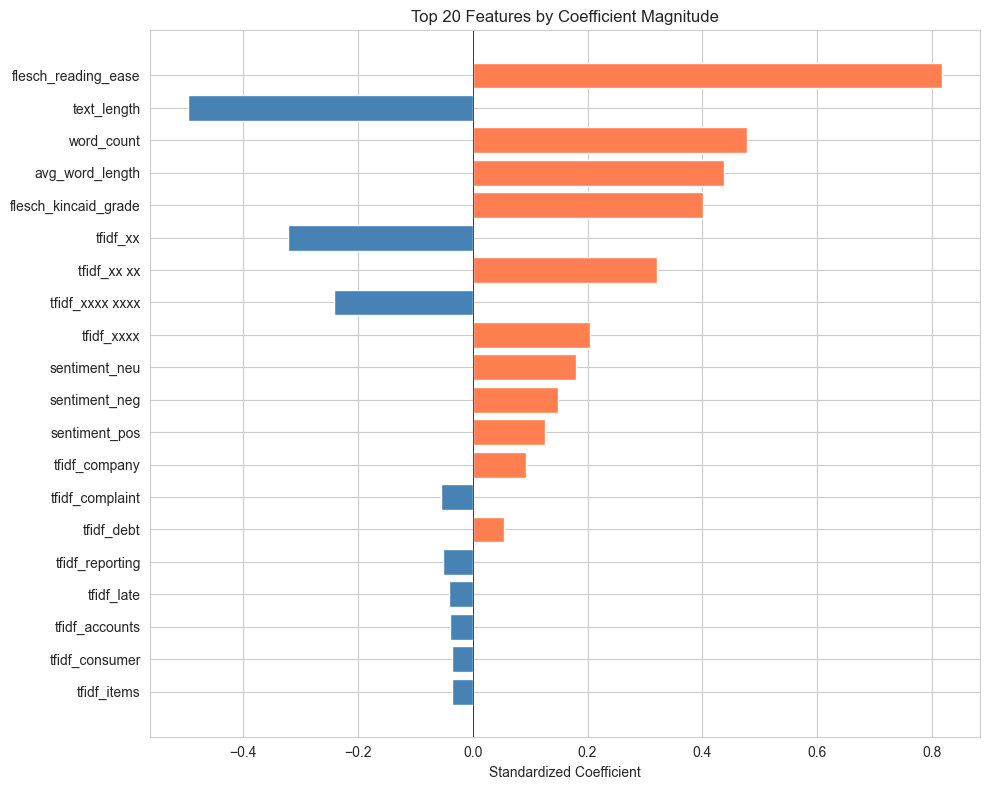

Coral = longer response time | Blue = shorter response time


In [16]:
# Visualize top coefficients
top_n = 20
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["coral" if c > 0 else "steelblue" for c in top_features["coefficient"]]
ax.barh(range(top_n), top_features["coefficient"].values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values)
ax.set_xlabel("Standardized Coefficient")
ax.set_title(f"Top {top_n} Features by Coefficient Magnitude")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Coral = longer response time | Blue = shorter response time")

In [17]:
import statsmodels.api as sm

# For statistical significance, we need statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Summary of just the significant features
results_df = pd.DataFrame({
    "feature": ["intercept"] + list(X.columns),
    "coefficient": ols_model.params,
    "std_error": ols_model.bse,
    "t_stat": ols_model.tvalues,
    "p_value": ols_model.pvalues,
})

significant = results_df[results_df["p_value"] < 0.05].sort_values("p_value")
print(f"Significant features (p < 0.05): {len(significant) - 1} out of {len(X.columns)}")
print()
significant.head(15).to_string(index=False)

Significant features (p < 0.05): 22 out of 61



'             feature  coefficient  std_error    t_stat       p_value\n           intercept     0.415045   0.011716 35.424953 1.183951e-270\n     tfidf_xxxx xxxx    -0.242479   0.024815 -9.771377  1.584109e-22\n          tfidf_xxxx     0.203937   0.024477  8.331715  8.220285e-17\n       tfidf_company     0.092642   0.012252  7.561494  4.070373e-14\n     tfidf_complaint    -0.055319   0.012863 -4.300452  1.708565e-05\n          tfidf_debt     0.054329   0.013298  4.085503  4.406774e-05\n         text_length    -0.495640   0.147018 -3.371297  7.488643e-04\n     tfidf_reporting    -0.051764   0.015744 -3.287809  1.010579e-03\n          word_count     0.478367   0.146769  3.259317  1.117748e-03\n flesch_reading_ease     0.817928   0.253886  3.221631  1.275660e-03\nflesch_kincaid_grade     0.401970   0.136926  2.935683  3.330050e-03\n      tfidf_accounts    -0.039490   0.013454 -2.935147  3.335808e-03\n     avg_word_length     0.438300   0.150644  2.909503  3.622047e-03\n         tfidf_item

**Reading these coefficients:**

> **Primer Reference**: [Section 10.2 — Interpreting Coefficients with Transformed Features](../Linear_Regression_Primer.md#102-interpreting-coefficients-with-transformed-features)

Since we standardized the features, each coefficient tells you: *"A 1 standard deviation increase in this feature is associated with X days change in response time."*

With 50K observations, many features will be statistically significant even if the effect is tiny. That's the difference between *statistical* significance and *practical* significance. A coefficient of 0.01 days is significant with enough data, but it means nothing in practice.

## 5. Checking Assumptions

> **Primer Reference**: [Section 3 — Assumptions](../Linear_Regression_Primer.md#3-assumptions-of-linear-regression) | [Section 9 — Diagnostics](../Linear_Regression_Primer.md#9-diagnostics)

Here's what most tutorials skip. Linear regression makes assumptions. Let's check if ours hold — and what to do when they don't.

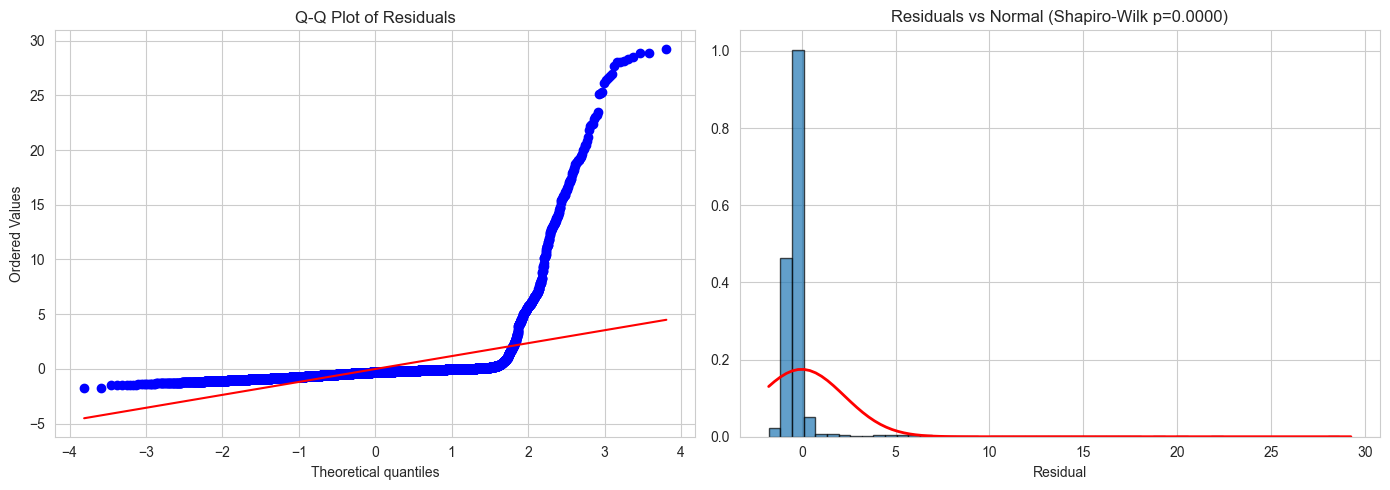

The residuals aren't normal. With count-like target data (days), they rarely are.
This doesn't invalidate the model — it means confidence intervals and p-values are approximate.
With 50K observations, the Central Limit Theorem has your back for coefficient estimates.


In [18]:
from scipy import stats

# Assumption 1: Normality of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot of Residuals")

# Shapiro-Wilk on a subsample (full dataset is too large for the test)
_, sw_p = stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=42))
axes[1].hist(residuals, bins=50, density=True, edgecolor="black", alpha=0.7)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), "r-", linewidth=2)
axes[1].set_title(f"Residuals vs Normal (Shapiro-Wilk p={sw_p:.4f})")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print("The residuals aren't normal. With count-like target data (days), they rarely are.")
print("This doesn't invalidate the model — it means confidence intervals and p-values are approximate.")
print("With 50K observations, the Central Limit Theorem has your back for coefficient estimates.")

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assumption 2: No multicollinearity
# Check VIF for hand-crafted features (not TF-IDF — those are sparse and numerous)
vif_data = pd.DataFrame()
X_vif = df[nlp_features].dropna()
vif_data["feature"] = nlp_features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF > 10 = problematic):")
print()
print(vif_data.to_string(index=False))
print()
print("High VIF between text_length and word_count? Obviously — longer text has more words.")
print("You could drop one, but keeping both doesn't bias coefficients — it just inflates their variance.")

Variance Inflation Factors (VIF > 10 = problematic):

             feature        VIF
       sentiment_neu 530.135460
 flesch_reading_ease 358.396750
          word_count 235.837553
         text_length 235.158154
     avg_word_length 215.888674
flesch_kincaid_grade 176.253320
       sentiment_neg  13.931807
       sentiment_pos  12.243429
  words_per_sentence  12.075010
      sentence_count   8.875213
  sentiment_compound   2.818187

High VIF between text_length and word_count? Obviously — longer text has more words.
You could drop one, but keeping both doesn't bias coefficients — it just inflates their variance.


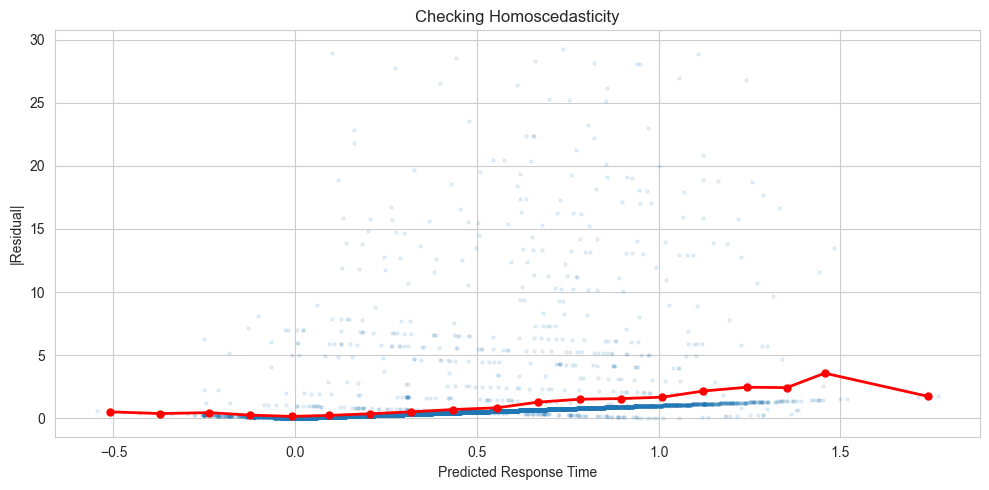

If that red line is flat, great. If it slopes up, you have heteroscedasticity.
With response time data, some heteroscedasticity is expected.
Fix: use robust standard errors (statsmodels HC3) or transform the target.


In [20]:
# Assumption 3: Homoscedasticity — constant variance of residuals
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, np.abs(residuals), alpha=0.1, s=5)

# Add a trend line to make the pattern clear
bins = pd.cut(y_pred, bins=20)
binned = pd.DataFrame({"pred": y_pred, "abs_resid": np.abs(residuals), "bin": bins})
bin_means = binned.groupby("bin", observed=True).agg({"pred": "mean", "abs_resid": "mean"}).dropna()
ax.plot(bin_means["pred"], bin_means["abs_resid"], "r-o", linewidth=2, markersize=5)

ax.set_xlabel("Predicted Response Time")
ax.set_ylabel("|Residual|")
ax.set_title("Checking Homoscedasticity")
plt.tight_layout()
plt.show()

print("If that red line is flat, great. If it slopes up, you have heteroscedasticity.")
print("With response time data, some heteroscedasticity is expected.")
print("Fix: use robust standard errors (statsmodels HC3) or transform the target.")

In [21]:
# Robust standard errors — the practical fix for heteroscedasticity
ols_robust = sm.OLS(y_train, X_train_sm).fit(cov_type="HC3")

# Compare: which features change significance with robust SEs?
comparison = pd.DataFrame({
    "feature": ["intercept"] + list(X.columns),
    "p_value_ols": ols_model.pvalues,
    "p_value_robust": ols_robust.pvalues,
})

# Features that lose significance with robust SEs
flipped = comparison[
    (comparison["p_value_ols"] < 0.05) & (comparison["p_value_robust"] >= 0.05)
]
if len(flipped) > 0:
    print("Features that LOSE significance with robust standard errors:")
    print(flipped[["feature", "p_value_ols", "p_value_robust"]].to_string(index=False))
    print("\nThese were false positives — their significance depended on the homoscedasticity assumption.")
else:
    print("All significant features remain significant with robust standard errors. Good.")

Features that LOSE significance with robust standard errors:
     feature  p_value_ols  p_value_robust
tfidf_agency     0.044567        0.077863

These were false positives — their significance depended on the homoscedasticity assumption.


### Common Pitfalls with NLP + Regression

**1. Too many TF-IDF features.** We used 50. If you crank it to 5,000, you'll overfit and your coefficients become meaningless. With linear regression, interpretability *is* the feature. Don't sacrifice it.

**2. Data leakage.** If any of your text features encode information about the *response* (not the complaint), you've got leakage. For example, if complaints mention "I waited 3 weeks" — that's the target leaking into the features.

**3. Confusing correlation with causation.** A longer complaint doesn't *cause* slower response. It might *correlate* with complaint complexity, which correlates with response time. Linear regression gives you associations, not causal effects.

**4. Ignoring the intercept.** The intercept is the predicted response time when all features are at their mean (since we standardized). It's your baseline — don't ignore it.

### 5.3. Leverage & Influence (Cook's Distance)

> **Primer Reference**: [Section 9.2 — Leverage and Influence](../Linear_Regression_Primer.md#92-leverage-and-influence)

An outlier has an unusual Y value. A high-leverage point has unusual X values. An *influential* point is one whose removal would substantially change the regression. Let's find them.

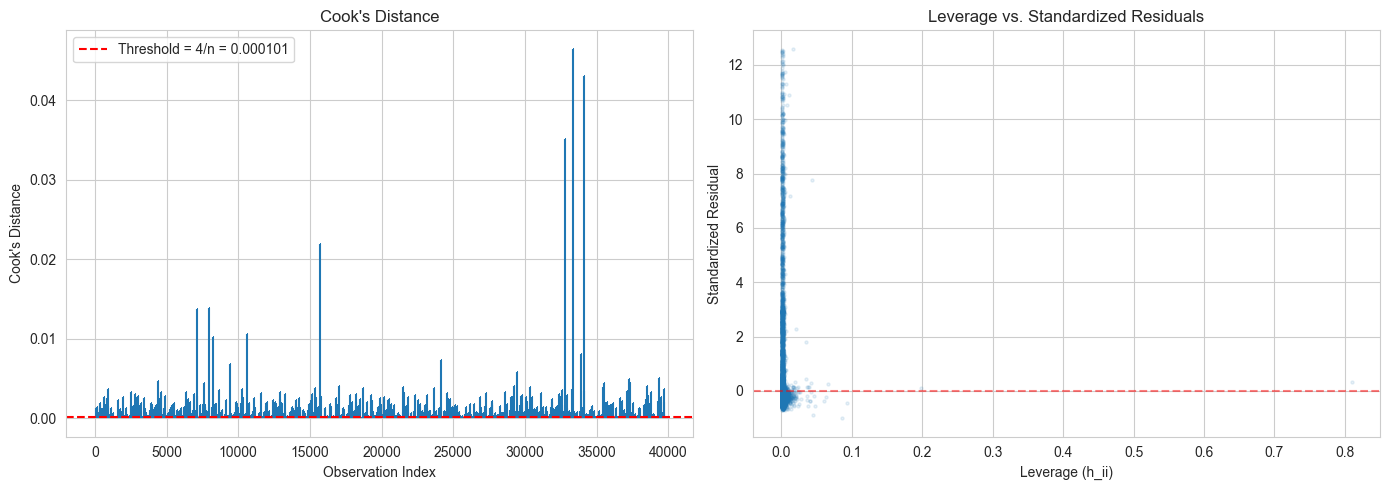

Observations exceeding Cook's distance threshold (4/n): 999 (2.5%)
Max Cook's distance: 0.0464

With 50K observations and many TF-IDF features, some influential points are expected.
These are complaints with unusual text patterns AND unusual response times.


In [22]:
# Cook's distance — which observations are driving the model?
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(ols_model)
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cook's distance stem plot
axes[0].stem(range(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
threshold = 4 / len(cooks_d)
axes[0].axhline(y=threshold, color="r", linestyle="--", label=f"Threshold = 4/n = {threshold:.6f}")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

# Leverage vs. residuals
leverage = influence.hat_matrix_diag
axes[1].scatter(leverage, ols_model.resid_pearson, alpha=0.1, s=5)
axes[1].set_xlabel("Leverage (h_ii)")
axes[1].set_ylabel("Standardized Residual")
axes[1].set_title("Leverage vs. Standardized Residuals")
axes[1].axhline(y=0, color="r", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

n_influential = (cooks_d > threshold).sum()
print(f"Observations exceeding Cook's distance threshold (4/n): {n_influential} ({n_influential/len(cooks_d)*100:.1f}%)")
print(f"Max Cook's distance: {cooks_d.max():.4f}")
print(f"\nWith 50K observations and many TF-IDF features, some influential points are expected.")
print("These are complaints with unusual text patterns AND unusual response times.")

## 6. Regularization: Ridge, Lasso, and Elastic Net

> **Primer Reference**: [Section 8 — Regularization](../Linear_Regression_Primer.md#8-regularization)

With 61 features (many of which are correlated TF-IDF terms and VIF-inflated hand-crafted features), this is a textbook case for regularization. Let's see if shrinking or zeroing out coefficients helps.

In [23]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Ridge: L2 penalty — shrinks coefficients but keeps all of them
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso: L1 penalty — sets some coefficients exactly to zero (variable selection)
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Elastic Net: mix of L1 and L2
enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9], alphas=np.logspace(-3, 3, 50),
                    cv=5, random_state=42, max_iter=10000)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)

# Compare all models
print(f"{'Model':<15} {'R² (test)':>10} {'RMSE':>10} {'MAE':>10} {'Non-zero coefs':>15}")
print("-" * 65)

for name, preds, mod in [
    ("OLS", y_pred, model),
    ("Ridge", y_pred_ridge, ridge),
    ("Lasso", y_pred_lasso, lasso),
    ("Elastic Net", y_pred_enet, enet),
]:
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    n_nonzero = np.sum(np.abs(mod.coef_) > 1e-10)
    print(f"{name:<15} {r2:>10.4f} {rmse:>10.4f} {mae:>10.4f} {n_nonzero:>15}")

print(f"\nRidge alpha:       {ridge.alpha_:.4f}")
print(f"Lasso alpha:       {lasso.alpha_:.4f}")
print(f"Elastic Net alpha: {enet.alpha_:.4f} (l1_ratio={enet.l1_ratio_:.1f})")

Model            R² (test)       RMSE        MAE  Non-zero coefs
-----------------------------------------------------------------
OLS                 0.0189     2.2824     0.7494              61
Ridge               0.0189     2.2824     0.7494              61
Lasso               0.0173     2.2843     0.7483              47
Elastic Net         0.0174     2.2842     0.7483              47

Ridge alpha:       2.6827
Lasso alpha:       0.0072
Elastic Net alpha: 0.0072 (l1_ratio=0.9)


Features Lasso dropped (set to zero): 14
['text_length', 'word_count', 'avg_word_length', 'flesch_kincaid_grade', 'sentiment_neg', 'sentiment_neu', 'sentiment_compound', 'tfidf_act', 'tfidf_credit reporting', 'tfidf_fair credit', 'tfidf_identity', 'tfidf_identity theft', 'tfidf_xx', 'tfidf_xxxx xx']


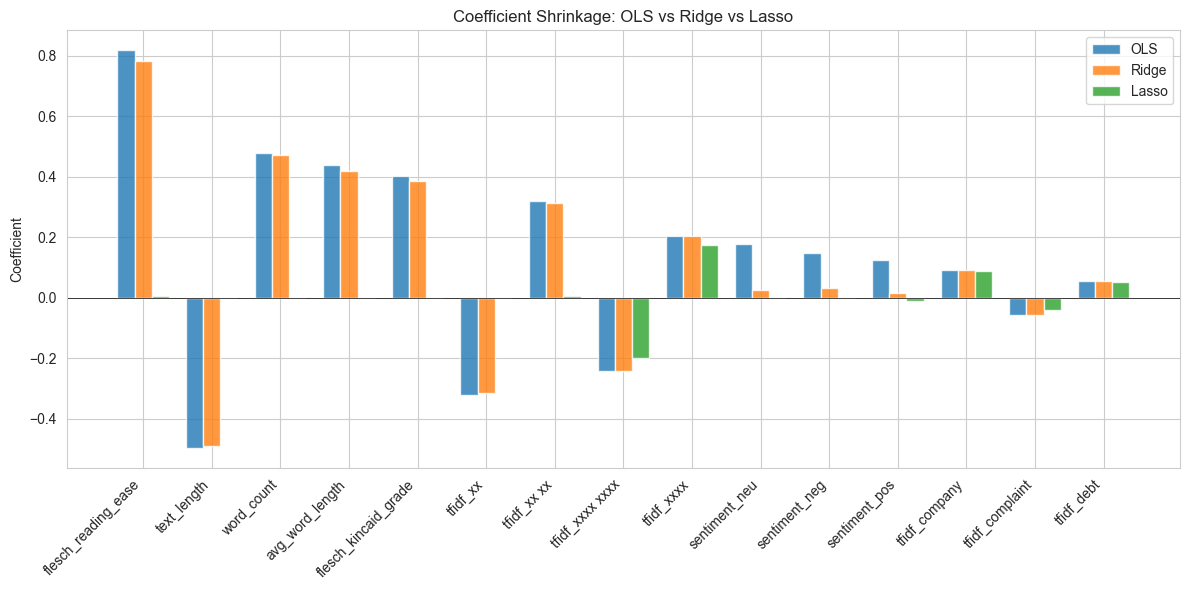

Notice how Ridge shrinks everything toward zero but keeps all features.
Lasso is more aggressive — it zeros out features it deems unhelpful.


In [24]:
# Coefficient comparison: OLS vs Ridge vs Lasso
coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "OLS": model.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
}).set_index("feature")

# Show features where Lasso zeroed out the coefficient
lasso_zeros = coef_comparison[coef_comparison["Lasso"] == 0]
print(f"Features Lasso dropped (set to zero): {len(lasso_zeros)}")
if len(lasso_zeros) > 0:
    print(lasso_zeros.index.tolist())

# Visualize coefficient shrinkage for top features
top_feats = coef_df.head(15)["feature"].values
coef_sub = coef_comparison.loc[top_feats]

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top_feats))
width = 0.25

ax.bar(x_pos - width, coef_sub["OLS"], width, label="OLS", alpha=0.8)
ax.bar(x_pos, coef_sub["Ridge"], width, label="Ridge", alpha=0.8)
ax.bar(x_pos + width, coef_sub["Lasso"], width, label="Lasso", alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(top_feats, rotation=45, ha="right")
ax.set_ylabel("Coefficient")
ax.set_title("Coefficient Shrinkage: OLS vs Ridge vs Lasso")
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Notice how Ridge shrinks everything toward zero but keeps all features.")
print("Lasso is more aggressive — it zeros out features it deems unhelpful.")

## 7. Log-Transforming the Target

> **Primer Reference**: [Section 7.4 — Log Transformations](../Linear_Regression_Primer.md#74-log-transformations)

Our target is right-skewed (most values are 0, long tail to 30). A log transform can help with heteroscedasticity and make the relationship more linear. Since we have zeros, we'll use $\log(Y + 1)$.

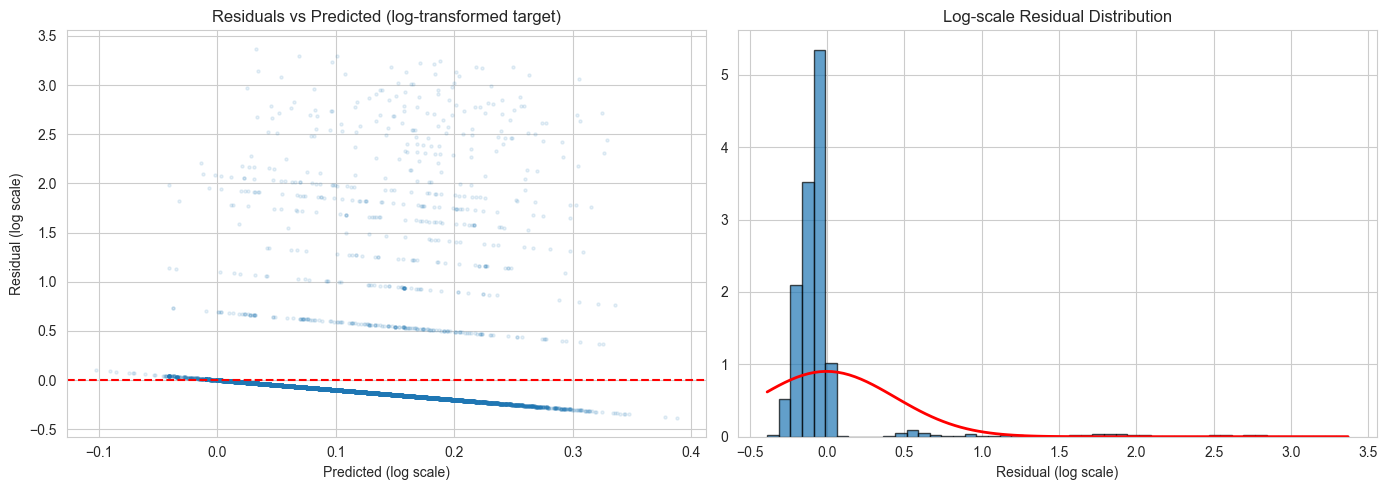

Comparison (original scale):
Model                      R²     RMSE      MAE
------------------------------------------------
OLS (original)         0.0189   2.2824   0.7494
OLS (log target)      -0.0065   2.3118   0.4904

Log-transforming the target changes coefficient interpretation:
  Now β_j means: a 1-SD increase in feature j is associated with
  approximately 100×β_j percent change in response time.


In [25]:
# Log-transform the target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Fit OLS on log-transformed target
model_log = LinearRegression()
model_log.fit(X_train_scaled, y_train_log)
y_pred_log = model_log.predict(X_test_scaled)

# Transform predictions back to original scale for comparison
y_pred_log_orig = np.expm1(y_pred_log)
y_pred_log_orig = np.maximum(y_pred_log_orig, 0)  # predictions can't be negative days

# Compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals on log scale
residuals_log = y_test_log - y_pred_log
axes[0].scatter(y_pred_log, residuals_log, alpha=0.1, s=5)
axes[0].axhline(y=0, color="r", linestyle="--")
axes[0].set_xlabel("Predicted (log scale)")
axes[0].set_ylabel("Residual (log scale)")
axes[0].set_title("Residuals vs Predicted (log-transformed target)")

# Histogram of log-scale residuals
axes[1].hist(residuals_log, bins=50, edgecolor="black", alpha=0.7, density=True)
x_range = np.linspace(residuals_log.min(), residuals_log.max(), 100)
axes[1].plot(x_range, stats.norm.pdf(x_range, residuals_log.mean(), residuals_log.std()), "r-", lw=2)
axes[1].set_xlabel("Residual (log scale)")
axes[1].set_title("Log-scale Residual Distribution")

plt.tight_layout()
plt.show()

# Metrics on original scale
print("Comparison (original scale):")
print(f"{'Model':<20} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 48)
print(f"{'OLS (original)':<20} {r2_score(y_test, y_pred):>8.4f} {np.sqrt(mean_squared_error(y_test, y_pred)):>8.4f} {mean_absolute_error(y_test, y_pred):>8.4f}")
print(f"{'OLS (log target)':<20} {r2_score(y_test, y_pred_log_orig):>8.4f} {np.sqrt(mean_squared_error(y_test, y_pred_log_orig)):>8.4f} {mean_absolute_error(y_test, y_pred_log_orig):>8.4f}")
print()
print("Log-transforming the target changes coefficient interpretation:")
print("  Now β_j means: a 1-SD increase in feature j is associated with")
print("  approximately 100×β_j percent change in response time.")

## 8. So What?

> **Primer Reference**: [Section 10 — Practical Considerations](../Linear_Regression_Primer.md#10-practical-considerations)

Here's what we learned:

**About the data:**
- Complaint text features have weak but real associations with response time
- The model's R² is low because response time is driven by company operations, not complaint content — and that's fine
- Specific words (from TF-IDF) are often more predictive than aggregate features like sentiment

**About linear regression with text data:**
- It works as an interpretability tool, not a prediction powerhouse
- Feature engineering matters more than model complexity
- Regularization (Ridge/Lasso) handles the multicollinearity we saw in VIF analysis — see how coefficients stabilize
- Always check your assumptions — they *will* be violated with real data. The question is how badly.
- Robust standard errors are your friend. Use them by default.

**About regularization:**
- Ridge shrank the inflated OLS coefficients but kept all features
- Lasso performed automatic variable selection — dropping features it deemed noise
- With highly correlated features (text_length & word_count), Lasso picks one; Ridge keeps both but shrinks them

**When to use this approach:**
- When you need to *explain* what text features matter, not just predict
- When stakeholders need a story, not a black box
- As a baseline before throwing deep learning at a problem

**When NOT to use it:**
- When prediction accuracy is all that matters (use gradient boosting or transformers)
- When your text features are all TF-IDF with thousands of dimensions (use Lasso or Ridge)
- When the relationship between text and target is clearly non-linear

**For the interview:** Be ready to explain *why* R² is low and why that's okay. Know the difference between statistical and practical significance. Be able to walk through when you'd choose OLS vs Ridge vs Lasso. See the [Primer Section 10.3](../Linear_Regression_Primer.md#103-common-interview-questions--answers) for common questions and answers.

In [26]:
# Final summary
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(f"Records:          {len(X):,}")
print(f"Features:         {X.shape[1]} ({len(nlp_features)} hand-crafted + {len(tfidf_feature_names)} TF-IDF)")
print(f"")
print(f"{'Model':<20} {'R² (test)':>10} {'RMSE':>10} {'MAE':>10}")
print("-" * 55)
print(f"{'OLS':<20} {r2_score(y_test, y_pred):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred)):>10.2f} {mean_absolute_error(y_test, y_pred):>10.2f}")
print(f"{'Ridge':<20} {r2_score(y_test, y_pred_ridge):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):>10.2f} {mean_absolute_error(y_test, y_pred_ridge):>10.2f}")
print(f"{'Lasso':<20} {r2_score(y_test, y_pred_lasso):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):>10.2f} {mean_absolute_error(y_test, y_pred_lasso):>10.2f}")
print(f"{'Elastic Net':<20} {r2_score(y_test, y_pred_enet):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_enet)):>10.2f} {mean_absolute_error(y_test, y_pred_enet):>10.2f}")
print(f"{'OLS (log target)':<20} {r2_score(y_test, y_pred_log_orig):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_log_orig)):>10.2f} {mean_absolute_error(y_test, y_pred_log_orig):>10.2f}")
print("=" * 60)
print(f"\nSignificant OLS vars (p<0.05): {len(significant) - 1}/{len(X.columns)}")
print(f"Lasso non-zero vars:           {np.sum(np.abs(lasso.coef_) > 1e-10)}/{len(X.columns)}")
print(f"\nSee the Linear Regression Primer for the theory behind all of this.")

MODEL SUMMARY
Records:          49,703
Features:         61 (11 hand-crafted + 50 TF-IDF)

Model                 R² (test)       RMSE        MAE
-------------------------------------------------------
OLS                      0.0189       2.28       0.75
Ridge                    0.0189       2.28       0.75
Lasso                    0.0173       2.28       0.75
Elastic Net              0.0174       2.28       0.75
OLS (log target)        -0.0065       2.31       0.49

Significant OLS vars (p<0.05): 22/61
Lasso non-zero vars:           47/61

See the Linear Regression Primer for the theory behind all of this.
